# 3H - Genese: o que separa as classes NOAA de El Nino?

**Pergunta especifica.** Que valores as variaveis assumem antes do onset dos eventos NOAA/ONI locais, e o estado precursor separa `fraco`, `moderado`, `forte` e `muito_forte`?

**Objetivo.** Compostos alinhados ao ONSET e ordenamento da intensidade final usando a classificacao NOAA baseada no pico da media movel de 3 meses.

**Justificativa.** A classificacao por percentis foi descartada. A genese deve comparar os niveis oficiais de intensidade e manter a media geral apenas como storyline fisico auxiliar.

**Metodologia.** Eventos = media movel 3 meses >=+0.5 C por 5+ estacoes sobrepostas. Compostos -52..+78 semanas do onset por classe NOAA; estado precursor em -26/-13/0 semanas; Spearman(estado precursor -26..0, intensidade final). **Area:** caixa Nino 3.4; WWV no Pacifico equatorial.

**Saidas.** `phase3H_proveniencia_eventos.csv`, `phase3H_compostos_onset.csv`, `phase3H_grupos_classes_noaa.csv`, `phase3H_estado_precursor_por_classe.csv`, `phase3H_separacao_genese.csv` + compostos, storyline e retrato.


In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u
w=pd.read_csv(u.FEAT/'phase3_indices_semanais.csv',parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
ev=u.events_noaa().copy()
prov=ev[['event_id','classe_noaa','event_start','peak_time','event_end','duration_oni_seasons','peak_oni_local_c','peak_monthly_ssta_c']].copy()
prov.columns=['evento','classe','onset','pico','fim','duracao_estacoes_oni','oni_pico_c','ssta_mensal_pico_c']
u.save_table(prov,'phase3H_proveniencia_eventos.csv',index=False)
counts=prov['classe'].value_counts().to_dict()
print('PROVENIENCIA NOAA/ONI local - '+', '.join(f'{k} n={counts.get(k,0)}' for k in u.ELNINO_MEAN_GROUP_ORDER))
print(prov[['evento','classe','onset']].to_string(index=False))


[tabela] data\processed\parquet\statistics\phase3H_proveniencia_eventos.csv
PROVENIENCIA NOAA/ONI local - fraco n=4, moderado n=2, forte n=3, muito_forte n=3
                 evento      classe      onset
el_nino_oisst_1982_1983 muito_forte 1982-07-01
el_nino_oisst_1986_1988    moderado 1986-10-01
el_nino_oisst_1991_1992       forte 1991-09-01
el_nino_oisst_1994_1995       fraco 1994-10-01
el_nino_oisst_1997_1998 muito_forte 1997-06-01
el_nino_oisst_2002_2003    moderado 2002-07-01
     el_nino_oisst_2004       fraco 2004-08-01
el_nino_oisst_2006_2007       fraco 2006-09-01
el_nino_oisst_2009_2010       forte 2009-07-01
el_nino_oisst_2014_2016 muito_forte 2014-10-01
el_nino_oisst_2018_2019       fraco 2018-10-01
el_nino_oisst_2023_2024       forte 2023-05-01


[tabela] data\processed\parquet\statistics\phase3H_grupos_classes_noaa.csv


[figura] data\processed\figures\fase3\phase3H_compostos_onset.png


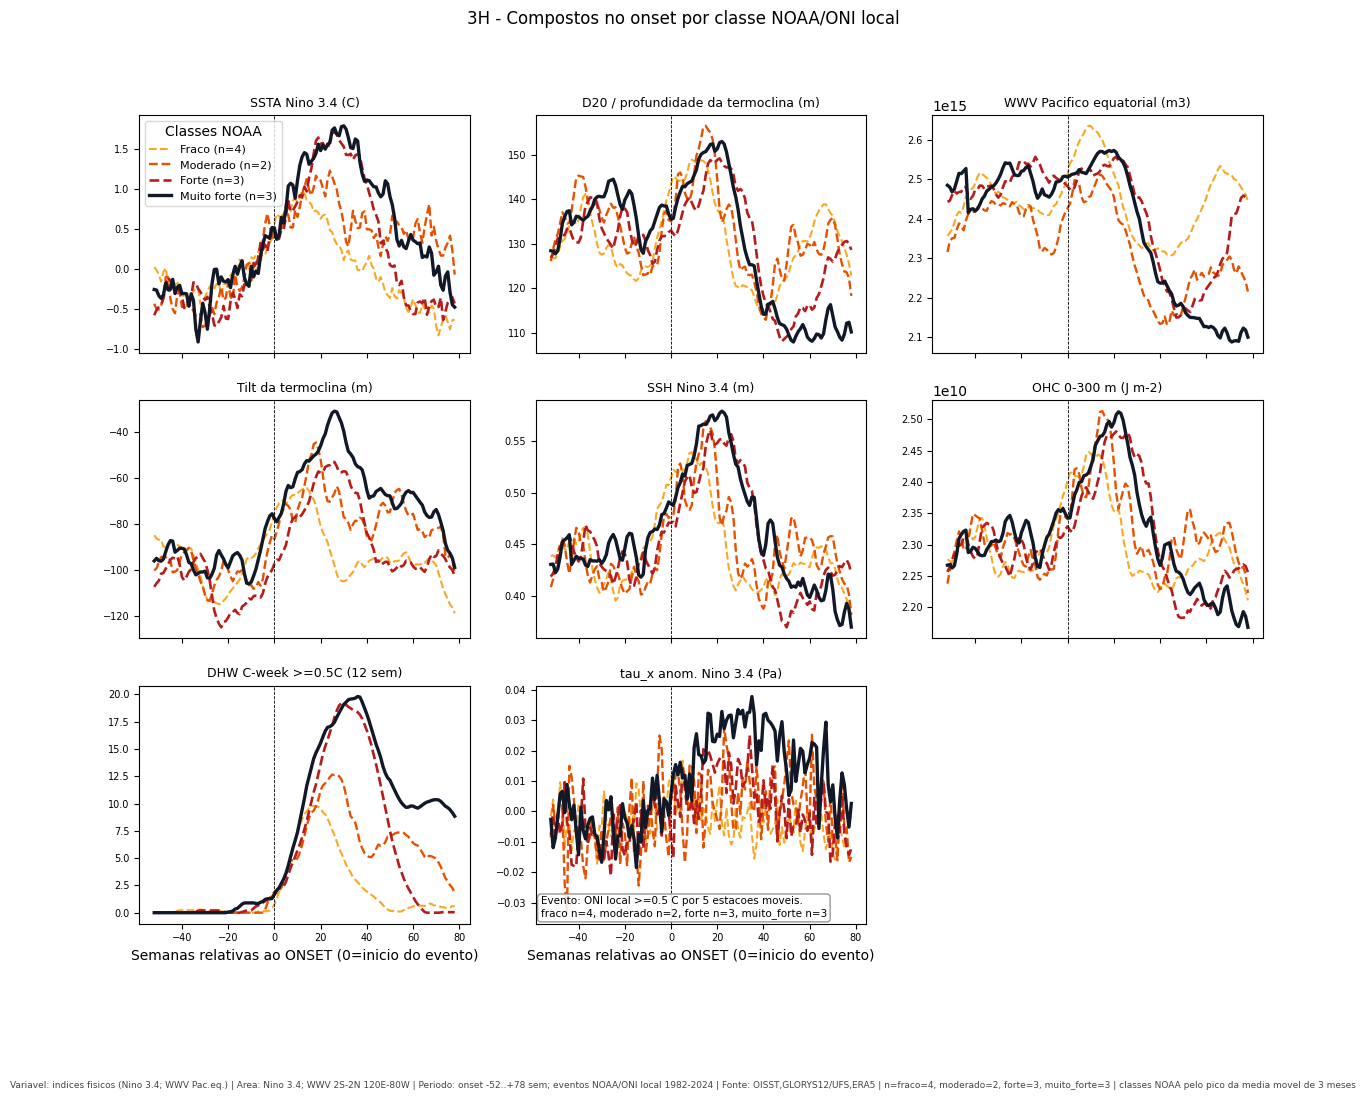

In [2]:
VARS=['nino34_ssta','d20_m','wwv','tilt_m','ssh_m','ohc_0_300','dhw_cweek_0p5_12w','tau_x_anom_nino34_pa']; LAGS=list(range(-52,79))
def onset_al(s,o):
    i=s.index.get_indexer([o],method='nearest')[0]; seg=s.iloc[max(0,i-52):i+79]
    rel=((seg.index-s.index[i]).days/7).round().astype(int); return pd.Series(seg.values,index=rel).reindex(LAGS)
groups=u.elnino_mean_groups(ev)
comps={g:pd.DataFrame({v:pd.DataFrame([onset_al(w[v],e.event_start) for _,e in gg.iterrows()]).mean() for v in VARS}) for g,gg in groups.items() if len(gg)>0}
comps['todos_elnino_noaa']=pd.DataFrame({v:pd.DataFrame([onset_al(w[v],e.event_start) for _,e in ev.iterrows()]).mean() for v in VARS})
pd.concat({g:v for g,v in comps.items() if g!='todos_elnino_noaa'},names=['grupo','sem_rel_onset']).to_csv(u.STATS/'phase3H_compostos_onset.csv')
u.save_table(u.elnino_mean_group_table()[['grupo','rotulo','definicao']],'phase3H_grupos_classes_noaa.csv',index=False)
fig,axes=plt.subplots(3,3,figsize=(14.5,10.5),sharex=True)
for ax,v in zip(axes.flat,VARS):
    for g in u.ELNINO_MEAN_GROUP_ORDER:
        if g in comps:
            meta=u.elnino_group_style(g)
            ax.plot(LAGS,comps[g][v],color=meta['color'],label=f"{meta['rotulo_curto']} (n={len(groups[g])})",lw=meta['linewidth'],ls=meta['linestyle'])
    ax.axvline(0,color='k',ls='--',lw=.6); ax.set_title(u.var_label(v),fontsize=9); ax.tick_params(labelsize=7)
axes.flat[0].legend(fontsize=8,title='Classes NOAA')
for ax in axes[-1]: ax.set_xlabel('Semanas relativas ao ONSET (0=inicio do evento)')
for ax in axes.flat[len(VARS):]: ax.axis('off')
counts=ev['classe_noaa'].value_counts().to_dict()
fig.suptitle('3H - Compostos no onset por classe NOAA/ONI local')
u.add_note(axes.flat[-2], 'Evento: ONI local >=0.5 C por 5 estacoes moveis.\n' + ', '.join(f'{k} n={counts.get(k,0)}' for k in u.ELNINO_MEAN_GROUP_ORDER), loc='lower left')
u.stamp_caption(fig,variavel='indices fisicos (Nino 3.4; WWV Pac.eq.)',area='Nino 3.4; WWV 2S-2N 120E-80W',periodo='onset -52..+78 sem; eventos NOAA/ONI local 1982-2024',fonte='OISST,GLORYS12/UFS,ERA5',n=', '.join(f"{k}={counts.get(k,0)}" for k in u.ELNINO_MEAN_GROUP_ORDER),extra='classes NOAA pelo pico da media movel de 3 meses')
u.save_fig(fig,'phase3H_compostos_onset.png'); plt.show()


[figura] data\processed\figures\fase3\phase3H_ciclo_vida.png


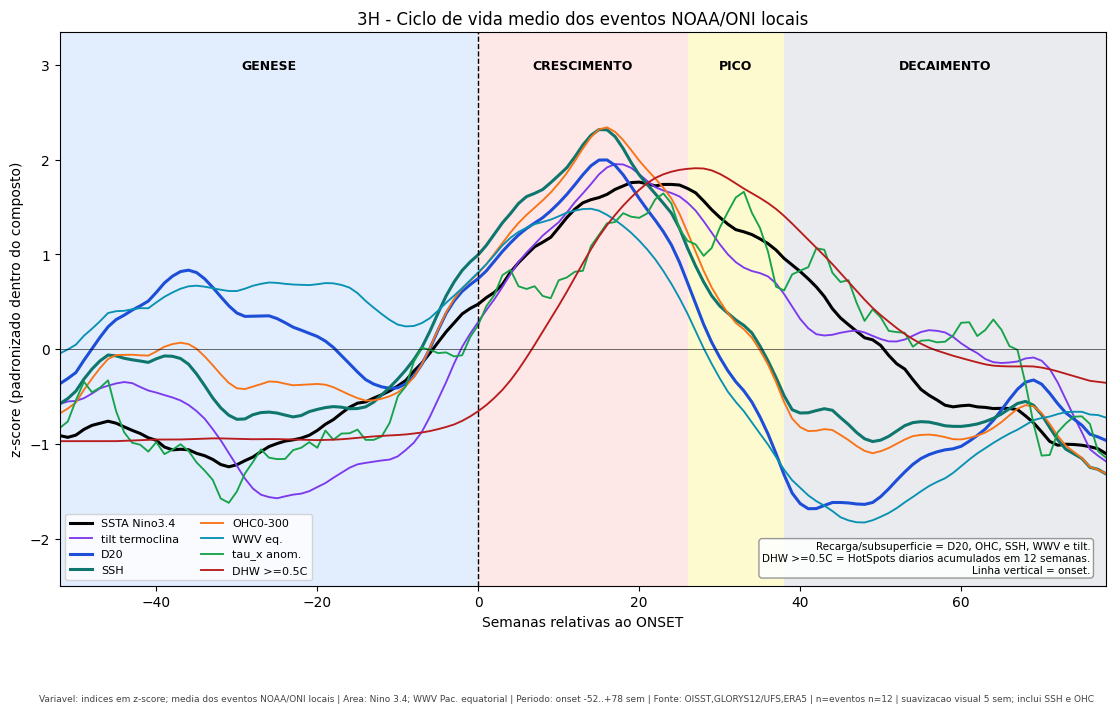

In [3]:
# storyline z-score da media geral dos eventos NOAA/ONI locais
zc=['nino34_ssta','tilt_m','d20_m','ssh_m','ohc_0_300','wwv','tau_x_anom_nino34_pa','dhw_cweek_0p5_12w']
classe_story='todos_elnino_noaa'
z=((comps[classe_story][zc]-comps[classe_story][zc].mean())/comps[classe_story][zc].std()).rolling(5,center=True,min_periods=1).mean()
fases=[(-52,0,'#dbeafe','GENESE'),(0,26,'#fee2e2','CRESCIMENTO'),(26,38,'#fef9c3','PICO'),(38,78,'#e5e7eb','DECAIMENTO')]
cores_l={'nino34_ssta':('#000','SSTA Nino3.4'),'tilt_m':('#7c3aed','tilt termoclina'),'d20_m':('#1d4ed8','D20'),'ssh_m':('#0f766e','SSH'),'ohc_0_300':('#f97316','OHC0-300'),'wwv':('#0891b2','WWV eq.'),'tau_x_anom_nino34_pa':('#16a34a','tau_x anom.'),'dhw_cweek_0p5_12w':('#b91c1c','DHW >=0.5C')}
fig,ax=plt.subplots(figsize=(13.5,7.2))
for x0,x1,c,r in fases:
    ax.axvspan(x0,x1,color=c,alpha=.8,lw=0)
    ax.text((x0+x1)/2,2.95,r,ha='center',fontsize=9,weight='bold')
for v,(c,l) in cores_l.items():
    ax.plot(z.index,z[v],color=c,lw=2.2 if v in('nino34_ssta','ssh_m','d20_m') else 1.35,label=l)
ax.axvline(0,color='k',ls='--',lw=1); ax.axhline(0,color='k',lw=.4); ax.set_xlim(-52,78); ax.set_ylim(-2.5,3.35)
ax.set_xlabel('Semanas relativas ao ONSET'); ax.set_ylabel('z-score (padronizado dentro do composto)'); ax.legend(loc='lower left',fontsize=8,ncol=2)
ax.set_title('3H - Ciclo de vida medio dos eventos NOAA/ONI locais')
u.add_note(ax, 'Recarga/subsuperficie = D20, OHC, SSH, WWV e tilt.\nDHW >=0.5C = HotSpots diarios acumulados em 12 semanas.\nLinha vertical = onset.', loc='lower right')
u.stamp_caption(fig,variavel='indices em z-score; media dos eventos NOAA/ONI locais',area='Nino 3.4; WWV Pac. equatorial',periodo='onset -52..+78 sem',fonte='OISST,GLORYS12/UFS,ERA5',n=f"eventos n={len(ev)}",extra='suavizacao visual 5 sem; inclui SSH e OHC')
u.save_fig(fig,'phase3H_ciclo_vida.png'); plt.show()


In [4]:
from scipy.stats import spearmanr
marcos=[-26,-13,0]; rows=[]
for g,gg in ev.groupby('classe_noaa'):
    for v in VARS:
        vals={m:[] for m in marcos}
        for _,e in gg.iterrows():
            s=onset_al(w[v],e.event_start)
            for m in marcos: vals[m].append(s.loc[m-2:m+2].mean())
        row={'classe':g,'variavel':v}
        for m in marcos:
            a=pd.Series(vals[m]).dropna(); row[f'media_{m}s']=round(a.mean(),3); row[f'range_{m}s']=f'{a.min():.2f}..{a.max():.2f}'
        rows.append(row)
u.save_table(pd.DataFrame(rows),'phase3H_estado_precursor_por_classe.csv',index=False)
rows=[]
for v in VARS:
    pre=[];it=[]
    for _,e in ev.iterrows():
        s=onset_al(w[v],e.event_start); pre.append(s.loc[-26:0].mean()); it.append(e.peak_oni_local_c if 'peak_oni_local_c' in e else e.peak_ssta_c)
    m=pd.notna(pre); rho,p=spearmanr(pd.Series(pre)[m],pd.Series(it)[m])
    rows.append({'variavel':v,'spearman_rho':round(float(rho),3),'p_bruto':round(float(p),3),'n':int(m.sum())})
sep=pd.DataFrame(rows).sort_values('spearman_rho',key=abs,ascending=False); u.save_table(sep,'phase3H_separacao_genese.csv',index=False)
print('SEPARACAO NA GENESE (Spearman estado precursor -26..0 vs pico ONI local; eventos NOAA):')
for _,r in sep.iterrows(): print(f"  {r.variavel:24s} rho={r.spearman_rho:+.2f} (p={r.p_bruto:.2f})")


[tabela] data\processed\parquet\statistics\phase3H_estado_precursor_por_classe.csv
[tabela] data\processed\parquet\statistics\phase3H_separacao_genese.csv
SEPARACAO NA GENESE (Spearman estado precursor -26..0 vs pico ONI local; eventos NOAA):
  d20_m                    rho=+0.55 (p=0.07)
  dhw_cweek_0p5_12w        rho=+0.36 (p=0.26)
  ohc_0_300                rho=+0.34 (p=0.28)
  wwv                      rho=+0.28 (p=0.38)
  tilt_m                   rho=+0.22 (p=0.50)
  ssh_m                    rho=+0.19 (p=0.56)
  tau_x_anom_nino34_pa     rho=+0.14 (p=0.67)
  nino34_ssta              rho=+0.06 (p=0.85)


**Leitura do 3H.** A genese agora compara as classes NOAA/ONI local: `fraco`, `moderado`, `forte` e `muito_forte`. A diferenca fisica continua concentrada no bloco de recarga/subsuperficie: D20/OHC/SSH/tilt aparecem antes do pico; SSTA/DHW sao mais diagnostico de fase/severidade do que causa antecipada. A leitura e descritiva, porque o n por classe e pequeno.
